# Synthetic biomarker benchmark — the shapes and what they settle

This notebook is the specification. Every shape below has values that follow from its geometry, and
those values are what a biomarker implementation is measured against — not another implementation's
opinion, and not a human's tracing.

**Why shapes at all.** A biomarker's name is not its definition: "tortuosity" names at least three
incompatible formulas, and papers usually report the name and omit the choice. Comparing two
programs tells you they differ without telling you which is right. A straight vessel has tortuosity
exactly 1, and that settles it.

**What it catches that a dataset cannot:** a factor of two in a curvature formula, a centreline
extractor that counts pixel steps where it should measure arc length, an arteriovenous ratio
computed from arteries alone, a measurement that moves when the vessel is rotated.

**Everything here is read from the store rather than drawn again.** The shapes are rendered once,
by `python -m benchmarks.shapes`, into `data/synthetic/av/`: a binary mask per class, a field of
view, a `manifest.csv` saying how each was framed, and a `ground_truth.csv` holding the values
each one\'s geometry requires. So the pictures below are the very files a benchmark measures, not a
second rendering that might differ from them.

How the benchmark is configured: [biomarker-synthetic-docs.md](../docs/benchmarks/biomarker-synthetic-docs.md).
The rules the shapes follow: `.claude/skills/build-benchmark/biomarker-synthetic.md`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def repository() -> Path:
    """The repository, found rather than assumed."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(f"nothing above {Path.cwd()} looks like the fundus-atlas repository")


ROOT = repository()
sys.path.insert(0, str(ROOT / "src"))

from benchmarks.shapes import library, store  # noqa: E402

STORE = ROOT / store.STORE
if not (STORE / "manifest.csv").exists():
    raise RuntimeError(f"no store at {STORE}: draw one with `python -m benchmarks.shapes`")

manifest = pd.DataFrame(store.read(STORE)).set_index("key")
truth = store.truth(STORE)

SIDE = int(manifest["side"].iloc[0])
UM_PER_PX = float(manifest["um_per_px"].iloc[0])
FAMILIES = list(dict.fromkeys(manifest["family"]))
ROTATIONS = sorted({float(angle) for angle in manifest["rotation"]})

print(f"{len(manifest)} renderings of {len(FAMILIES)} families, read from {STORE.relative_to(ROOT)}")
print(f"{SIDE}² px at {UM_PER_PX:g} µm per pixel — a frame {SIDE * UM_PER_PX / 1000:.1f} mm across")
print(f"rotations: {', '.join(f'{angle:g}°' for angle in ROTATIONS)}")
print(f"arteries {float(manifest['artery_width_um'].iloc[0]):g} µm, "
      f"veins {float(manifest['vein_width_um'].iloc[0]):g} µm, "
      f"optic disc {float(manifest['disc_diameter_um'].iloc[0]):g} µm across")

32 renderings of 8 families, read from data/synthetic/av
2048² px at 5 µm per pixel — a frame 10.2 mm across
rotations: 0°, 30°, 60°, 90°
arteries 80 µm, veins 120 µm, optic disc 1800 µm across


## 1. The shapes

Each is drawn from a centreline in continuous coordinates and rasterised once — never drawn small
and enlarged, and never rotated as a picture, because resampling a structure a few pixels wide
destroys it. Turning is done to the geometry and the scene is drawn again, so the pixel grid is the
only difference between one angle and another.

**Arteries are red, veins are blue**, the field of view is the dark circle, the optic disc is the
gold ring and the two faint rings are the annulus the central retinal equivalents are measured over
— two and three disc radii out.

**Every shape carries both classes.** A segmentation of a real eye has arteries and veins in it, so
a shape offering only one would test something no implementation ever meets; it also means every
family pins the ratio of the two calibres, which is the one arteriovenous quantity needing neither
disc nor ring.

Widths and the disc are given in **microns** and become pixels through the scale: an 80 µm artery
is 16 px across at 5 µm per pixel. The same shape at another resolution is the same retina
photographed again, not a different retina.

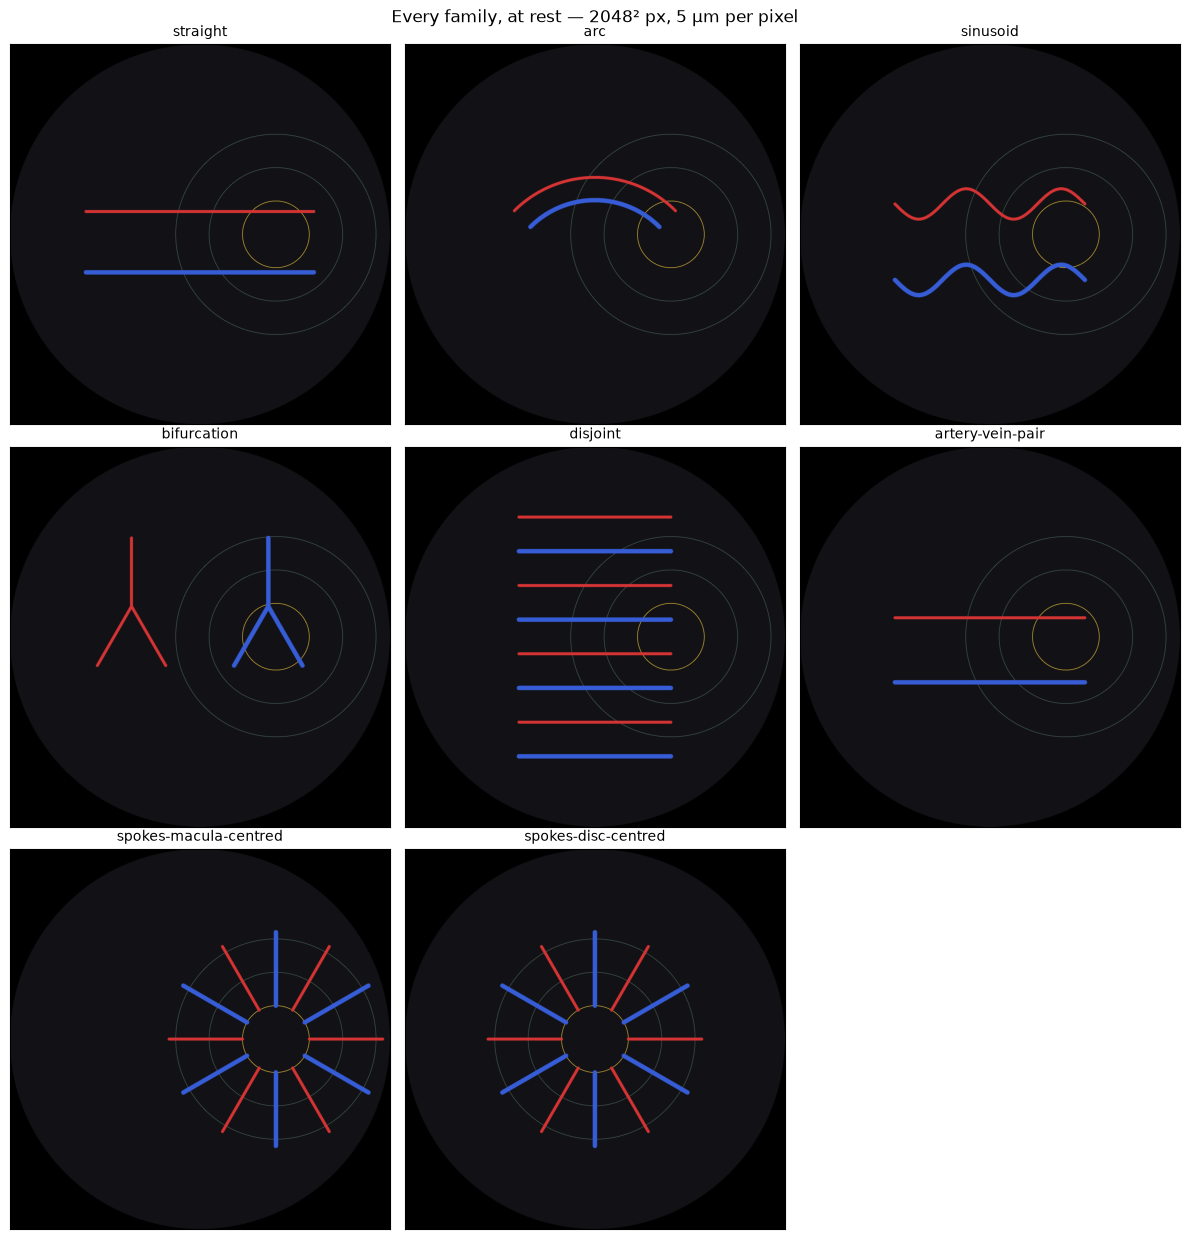

In [2]:
def picture(key: str, axis, title: str | None = None) -> None:
    """One stored rendering, exactly as an implementation is handed it."""
    rendering = store.load(STORE, key)
    axis.imshow(library.demo_image(rendering))
    axis.set_title(title or f"{rendering.family}\n{rendering.rotation:g}°", fontsize=10)
    axis.set_xticks([])
    axis.set_yticks([])


at_rest = [f"{family}-{SIDE}-000" for family in FAMILIES]
fig, axes = plt.subplots(3, 3, figsize=(12, 12.6))
for axis in axes.ravel()[len(at_rest):]:
    axis.set_visible(False)
for axis, key in zip(axes.ravel(), at_rest):
    picture(key, axis, title=manifest.loc[key, "family"])
fig.suptitle(f"Every family, at rest — {SIDE}² px, {UM_PER_PX:g} µm per pixel", fontsize=12)
fig.tight_layout()

### 1.1 The same shape, turned

Four angles of one family. The vessel does not change; only which pixels it lands on does. A
measurement that moves across this row is reading the lattice rather than the retina — which is
exactly what the benchmark found PVBM's tortuosity doing.

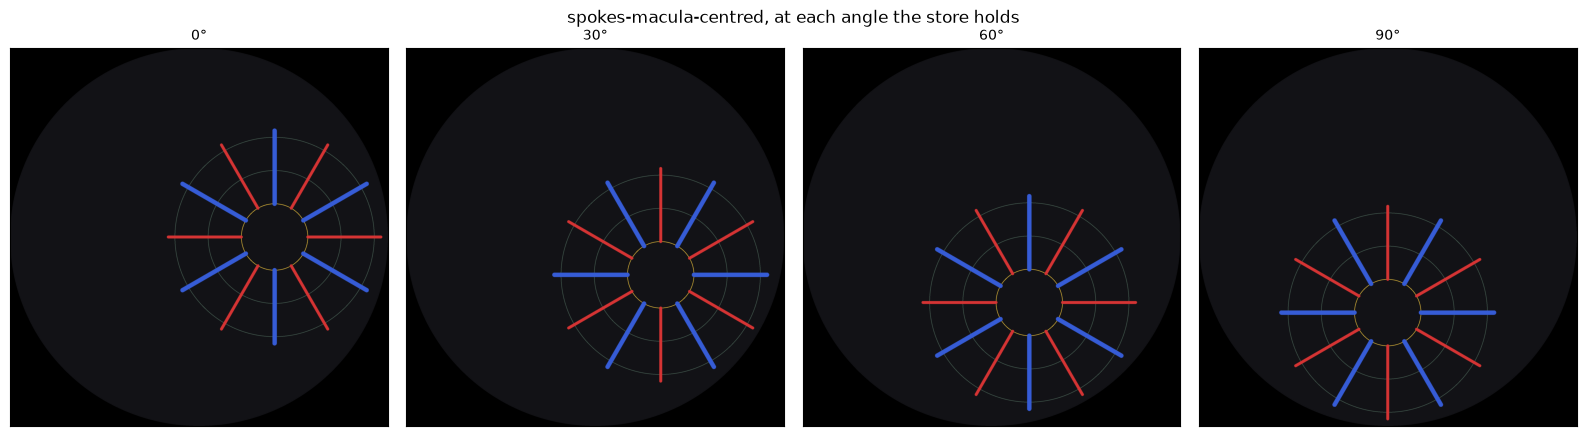

In [3]:
family = "spokes-macula-centred"
fig, axes = plt.subplots(1, len(ROTATIONS), figsize=(4 * len(ROTATIONS), 4.4))
for axis, angle in zip(np.atleast_1d(axes), ROTATIONS):
    picture(f"{family}-{SIDE}-{round(angle):03d}", axis, title=f"{angle:g}°")
fig.suptitle(f"{family}, at each angle the store holds", fontsize=12)
fig.tight_layout()

## 2. What each shape settles

This is `ground_truth.csv`, read back: one row per quantity, one column per family, keyed as
`biomarker/variant/structure` after the catalogue in `docs/biomarkers/` — so a number an
implementation returns is compared with the right definition rather than with whichever happens to
share its name.

An empty cell means the shape says nothing about that quantity, **which is not the same as zero**:
a straight vessel does not have a central retinal equivalent of nought, it has none at all.

The values do not depend on the angle, which is the point of them — so one column per family is
enough, and the four rotations of each carry the same numbers.

In [4]:
theory = pd.DataFrame(
    {family: truth[f"{family}-{SIDE}-000"] for family in FAMILIES}
).sort_index()
theory.index.name = "biomarker / variant / structure"
assert all(
    truth[f"{family}-{SIDE}-{round(angle):03d}"] == truth[f"{family}-{SIDE}-000"]
    for family in FAMILIES
    for angle in ROTATIONS
), "a rotation changed what the geometry requires, which it must never do"
theory.round(4).style.set_table_styles(
    [
        {"selector": "th.row_heading", "props": [("text-align", "left")]},
        {"selector": "th.index_name", "props": [("text-align", "left")]},
    ]
)

,straight,arc,sinusoid,bifurcation,disjoint,artery-vein-pair,spokes-macula-centred,spokes-disc-centred
biomarker / variant / structure,,,,,,,,
avr/hubbard/both,nan,nan,nan,nan,nan,nan,0.674400,0.674400
avr/knudtson/both,nan,nan,nan,nan,nan,0.666700,0.545300,0.545300
avr/ratio-of-calibres/both,0.666700,0.666700,0.666700,0.666700,0.666700,0.666700,0.666700,0.666700
bifurcation-angle/between-daughters/artery,nan,nan,nan,60.000000,nan,nan,nan,nan
bifurcation-angle/between-daughters/vein,nan,nan,nan,60.000000,nan,nan,nan,nan
central-retinal-equivalents/hubbard/artery,nan,nan,nan,nan,nan,nan,151.721700,151.721700
central-retinal-equivalents/hubbard/vein,nan,nan,nan,nan,nan,nan,224.984600,224.984600
central-retinal-equivalents/knudtson/artery,nan,nan,nan,nan,nan,16.000000,27.974900,27.974900
central-retinal-equivalents/knudtson/vein,nan,nan,nan,nan,nan,24.000000,51.302700,51.302700


## 3. The derivations

Each value above follows from the geometry, and each is stated here so that a reader can disagree
with the arithmetic rather than with the code.

### 3.1 Straight vessel

Tortuosity is **exactly 1** under any arc-over-chord definition, because the arc *is* the chord.
Total curvature is **exactly 0**. The calibre is the width it was drawn at. Its area is the width
times the length, plus a disc of that width for the two rounded ends — the two-dimensional tube
formula, which holds for any curve that does not cross itself.

This is the shape that catches the most basic error available: an implementation whose tortuosity
is not 1 here is not computing tortuosity.

### 3.2 Circular arc

Curvature is **exactly 1/r** everywhere. Arc length is `rθ`, the chord is `2r sin(θ/2)`, so

$$\tau_1 = \frac{r\theta}{2r\sin(\theta/2)} = \frac{\theta}{2\sin(\theta/2)}$$

in which **`r` cancels**. That is the useful part: τ1 depends on how far the vessel bends and not at
all on how large it is, so an implementation whose τ1 changes with the radius is computing
something else. Total curvature is `θ`; total squared curvature is `θ/r`.

### 3.3 Sinusoid

Its arc length is an elliptic integral with no elementary closed form, so the theory *is* the
integral — evaluated over 200,001 points, which is exact to far more places than any implementation
will reach. The same integration gives `∫κ ds` and `∫κ² ds`, with

$$\kappa = \frac{|y''|}{(1 + y'^2)^{3/2}}$$

A curve with curvature that varies along its length is what separates an implementation that
integrates properly from one that averages a few sampled points.

### 3.4 Bifurcation

Symmetric, so the angle between the daughters is exactly the angle asked for and neither daughter
is the trunk. One junction, three endpoints, one connected component.

### 3.5 Parallel vessels that never meet

No junctions, and as many components as there are lines. A skeletoniser that joins them, or a
junction counter that finds a crossing where two vessels merely pass near one another, says so here
and nowhere else.

### 3.6 Artery beside vein

Two vessels of constant widths `wa` and `wv`, far from the disc. Their ratio of calibres is
**exactly `wa / wv`**.

What this shape deliberately does **not** promise is a central retinal equivalent. Those are
measured over a ring around the optic disc, and vessels that never cross that ring cannot produce
one — so an implementation that returns a CRAE here is measuring something it was not given, which
is a finding rather than a value. That was wrong in the first version of this notebook, where the
shape claimed `CRAE = wa`.

### 3.7 Spokes from the disc

The shape the central retinal equivalents actually need. Six arteries and six veins radiate from
the disc margin past three disc radii, so every one of them crosses the annulus between **two and
three disc radii** that PVBM builds as zone C minus zone B — the region
[central-retinal-equivalents.md](../docs/biomarkers/central-retinal-equivalents.md) §5 records, and
the one the classical convention states in disc *diameters*, a factor-of-two trap when reading code.

All arteries share one width and all veins share another, which makes the theory unambiguous:
Knudtson's recursion pairs the widest vessel with the narrowest, the next widest with the next
narrowest, and combines each pair as `k·√(w₁² + w₂²)` — `k` being 0.88 for arterioles and 0.95 for
venules — repeating until one number is left. With six equal widths **every pairing order gives the
same answer**, so the shape tests the formula and the region rather than an implementation's
sorting convention. A shape with unequal widths would test the convention and have no single
correct answer to test it against.

The two classes alternate around the disc so that neither is bunched on one side, where a
temporal-only or half-ring convention would miss it.

## 4. A rasterised shape is not the shape

The theory describes a continuous curve; an implementation sees pixels. The difference is real and
is nobody's bug — and it is why this benchmark renders every shape at several resolutions rather
than judging at one.

Below: the area actually drawn, against the area the geometry requires, as the grid refines.

**Expect a sawtooth, not a smooth curve.** What separates the two is at most one row of pixels along
the vessel, and whether that row is taken depends on where the centreline falls between pixel
centres. The error can therefore rise between two resolutions with nothing wrong. Read the trend
across four, never the step between two.

In [5]:
rows = []
for side in (256, 512, 1024, 2048):
    # Built rather than read: the store holds one grid, and this asks what changes between grids.
    shape = library.build("straight", side=side, um_per_px=UM_PER_PX)
    drawn = float(shape.artery.sum())
    required = shape.theory["vessel-area-and-length/area/artery"]
    rows.append(
        {
            "side": side,
            "artery width, px": round(shape.parameters["artery_width"], 1),
            "area drawn": drawn,
            "area geometry requires": required,
            "relative difference": drawn / required - 1.0,
            "one row of pixels would be": 1.0 / shape.parameters["artery_width"],
        }
    )
pd.DataFrame(rows).set_index("side").round(4)

,"artery width, px",area drawn,area geometry requires,relative difference,one row of pixels would be
side,,,,,
256,16.0,2660.0,2658.6619,0.0005,0.0625
512,16.0,5118.0,5116.2619,0.0003,0.0625
1024,16.0,10028.0,10031.4619,-0.0003,0.0625
2048,16.0,19860.0,19861.8619,-0.0001,0.0625


## 5. The one place the scale matters

Nothing above depends on how many microns a pixel is worth: a tortuosity is a ratio, a junction is
a junction, and a calibre in pixels is a calibre in pixels. **The central retinal equivalents are
the exception**, and the two variants behave in opposite ways.

Because a vessel's width is stated in **microns** here, photographing the same retina at a finer
scale draws the same vessel across more pixels. So:

- **Knudtson** combines each pair as `k·√(w₁² + w₂²)` with `k` = 0.88 for arterioles and 0.95 for
  venules. It is purely multiplicative and therefore scale-*free* — which means computed on pixel
  widths it comes out in pixels, and **moves with the resolution**: halve the microns per pixel and
  it doubles. It is the same calibre reported in a different unit.
- **Hubbard** combines them as `√(a·w₁² + b·w₂² + c·w₁w₂ + d)` with coefficients fitted in
  **microns** — and the additive `d`, −10.76 for arterioles and +450.05 for venules, **does not
  scale**. Given micron widths it returns microns, and the answer does not move with the
  resolution, because the eye did not change. Given *pixel* widths it returns a different quantity
  wearing the same name, which is the defect the benchmark found in PVBM.

The table below is the same retina at three resolutions. Knudtson's pixel answer moves; Hubbard's
micron answer does not; and every ratio built from either is invariant.

**The three arteriovenous ratios are three different numbers on the same vessels** — the plain
ratio of calibres, Knudtson's, and Hubbard's. What separates Hubbard's from the plain ratio is not
the resolution but the *vessels*: double every width and the first two are unchanged while
Hubbard's moves, because an additive constant cannot scale.

In [6]:
rows = []
for scale in (5.0, 10.0, 20.0):
    for name in ("artery-vein-pair", "spokes-macula-centred"):
        shape = library.build(name, side=2048, um_per_px=scale)
        rows.append(
            {
                "shape": name,
                "µm per pixel": scale,
                "artery, px": shape.parameters["artery_width"],
                "CRAE Knudtson, px": shape.theory.get("central-retinal-equivalents/knudtson/artery"),
                "CRAE Hubbard, µm": shape.theory.get("central-retinal-equivalents/hubbard/artery"),
                "AVR, calibres": shape.theory.get("avr/ratio-of-calibres/both"),
                "AVR, Knudtson": shape.theory.get("avr/knudtson/both"),
                "AVR, Hubbard": shape.theory.get("avr/hubbard/both"),
            }
        )
# An empty Hubbard cell on the pair is the point of that shape: one artery and one vein cross the
# ring, Knudtson's recursion passes a lone vessel through untouched, and Hubbard's combines a pair
# and so has nothing to combine. An implementation must decline there rather than invent a vessel.
pd.DataFrame(rows).set_index(["shape", "µm per pixel"]).round(3)

,,"artery, px","CRAE Knudtson, px","CRAE Hubbard, µm","AVR, calibres","AVR, Knudtson","AVR, Hubbard"
shape,µm per pixel,,,,,,
artery-vein-pair,5.0,16.0,16.000,NaN,0.667,0.667,NaN
spokes-macula-centred,5.0,16.0,27.975,151.722,0.667,0.545,0.674
artery-vein-pair,10.0,8.0,8.000,NaN,0.667,0.667,NaN
spokes-macula-centred,10.0,8.0,13.987,151.722,0.667,0.545,0.674
artery-vein-pair,20.0,4.0,4.000,NaN,0.667,0.667,NaN
spokes-macula-centred,20.0,4.0,6.994,151.722,0.667,0.545,0.674


## 6. What this benchmark does not test

- **Cup-to-disc ratio.** An adapter is handed the disc as a centre and a radius and is given no
  cup, so the ratio cannot be formed. It is measured against ophthalmologists' own outlines in the
  [disc benchmark](../docs/benchmarks/disc-results.md) instead.
- **Anything anchored to the fovea** — the disc-fovea distance, and the temporal angle — because a
  synthetic shape has no macula and inventing one would make the answer a property of the fixture.
- **Vessel tracing**, which is a step rather than a number.
- **Whether an implementation works on a photograph.** A program that measures a synthetic vessel
  exactly may still fail on a segmentation of a real eye, which is the next benchmark's question.